<a href="https://colab.research.google.com/github/redsheep913/generative_ai/blob/main/%E7%94%9F%E6%88%90%E5%BC%8FAI_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎨 AI **創意圖像生成工作室**

## 一、模型架構與技術選擇

在這個專案中，我採用了一個多層次的 AI 模型架構來實現智慧化的提示詞轉換和圖像生成工作流程。這種架構的設計體現了現代 AI 應用開發中的重要原則：專業分工和協作優化。

核心的語言處理部分使用了 Groq 平台上的 Llama3-70B-8192 模型。選擇這個模型有幾個重要的技術考量。首先，Llama3-70B 在自然語言理解和生成方面表現出色，特別是在處理中英文轉換和創意文本生成任務時。其 70 億參數的規模為複雜的語言處理任務提供了足夠的表達能力，同時 8192 的上下文長度確保了系統能夠處理詳細的提示詞描述和複雜的多輪對話。

圖像生成部分則採用了 Lykon/dreamshaper-8 模型。這個模型是專門針對高品質圖像生成進行優化的，特別擅長生成具有藝術感和寫實感的圖像。Dreamshaper-8 在色彩表現、細節刻畫和風格一致性方面都有優異的表現，這使它成為創意圖像生成的理想選擇。

這種雙模型架構的設計哲學在於讓每個 AI 系統專注於其最擅長的領域。語言模型負責理解用戶意圖、轉換描述語言和提供專業建議，而圖像模型則專注於將優化後的提示詞轉化為視覺作品。這種分工合作的方式不僅提高了系統的整體性能，也為用戶提供了更加專業和可靠的創作體驗。

## 二、專案目標與教育理念

這個專案的核心目標是構建一個教育導向的 AI 輔助創作平台，幫助用戶掌握有效的人機協作技能。在當今 AI 技術快速發展的時代，能夠有效地與 AI 系統協作已經成為一項重要的數位素養。然而，許多用戶在使用 AI 圖像生成工具時經常遇到一個共同的挑戰：如何將腦海中的視覺想像準確地傳達給 AI 系統。

我希望通過這個專案解決幾個層面的問題。在技術層面，系統要能夠智慧地將中文的圖像描述轉換為專業的英文提示詞，這不僅僅是語言翻譯，更是一種概念重構和技術優化的過程。在教育層面，我希望用戶能夠通過觀察系統的三階段處理流程，逐漸理解什麼構成了一個優質的圖像生成提示詞，從而培養出獨立創作的能力。

這個專案還體現了一種重要的教育哲學：透明化的學習過程。傳統的 AI 工具往往像黑盒子一樣，用戶輸入內容，系統產出結果，但中間的處理過程完全不可見。我的設計刻意讓整個優化過程變得透明可見，用戶可以觀察 AI 是如何理解他們的描述，專業審查者是如何分析和改進提示詞的，以及最終版本是如何整合所有建議的。這種透明化的設計讓工具本身成為了一個學習環境。

更深層的目標是培養用戶的批判性思維和創作能力。通過觀察和參與這個反思式的創作過程，用戶不僅獲得了更好的圖像生成結果，更重要的是學會了如何思考、如何評估、如何改進。這些技能在 AI 時代將變得越來越重要。

## 三、專案開發過程與關鍵決策

整個專案的開發過程體現了從概念設計到技術實現的完整旅程，每個階段都有其獨特的挑戰和學習價值。

**系統架構設計階段**

最初的系統設計靈感來自於人類創作過程中的自然協作模式。當我們觀察專業的創作環境，比如廣告公司或設計工作室，會發現優秀的作品往往來自於多個角色的協作：創意總監提出初步想法，設計師進行具體實現，資深顧問提供專業建議，然後創意團隊根據反饋進行迭代改進。

我將這種協作模式抽象為 AI 系統的設計架構。Writer 模型扮演創意轉換者的角色，負責將用戶的中文描述轉化為基礎的英文提示詞。Reviewer 模型則扮演專業顧問的角色，從技術規範、藝術原理和實用性等多個維度評估提示詞的品質。最後，Writer 模型再次發揮作用，整合專業建議產出最終的優化版本。

**核心算法實現階段**

在實現 `reflect_post` 函數時，我面臨的主要挑戰是如何確保三個階段之間的有效銜接。每個階段都需要清晰的任務定義和適當的上下文管理。最終的解決方案採用了模組化的設計理念，每個階段都有獨立的處理邏輯，同時通過精心設計的提示詞來確保階段間的語義連貫性。

```python
def reflect_post(prompt):
    # 第一階段：基礎轉換
    first_version = reply(system_writer, prompt,
                          provider=provider_writer,
                          model=model_writer)

    # 第二階段：專業審查
    suggestion = reply(system_reviewer, first_version,
                       provider=provider_reviewer,
                       model=model_reviewer)

    # 第三階段：綜合優化
    improvement_prompt = f"""原始轉換：{first_version}
    
    專業建議：{suggestion}
    
    請根據建議重新優化這個英文 prompt，直接輸出改進版本。"""
    
    second_version = reply(system_writer, improvement_prompt,
                           provider=provider_writer,
                           model=model_writer)

    return first_version, suggestion, second_version
```

這個實現的關鍵在於每個階段的提示詞設計。Writer 的系統提示詞專門針對圖像生成進行了優化，包含了豐富的視覺描述技巧和技術參數指導。Reviewer 的系統提示詞則側重於專業評估標準和具體改進建議。

**用戶介面設計與迭代**

Gradio 介面的設計經歷了多次迭代，每次迭代都基於對用戶體驗的深入思考。最初的設計相對簡單，主要關注功能實現。但隨著對教育價值的重視，介面逐漸演化為一個綜合的學習環境。

標籤頁的設計體現了循序漸進的學習理念。第一個標籤頁專注於提示詞轉換的學習和實踐，用戶可以詳細觀察整個優化過程。第二個標籤頁則進入實際的圖像生成階段，讓用戶體驗如何將優化的提示詞轉化為視覺作品。第三個標籤頁提供了快速工作流程，適合已經熟悉系統的用戶。第四個標籤頁則是深度學習資源，幫助用戶建立理論基礎。

工作流程的連接設計特別值得討論。最初我考慮了自動化的解決方案，比如自動切換標籤頁或直接觸發圖像生成。但經過深入思考，我意識到保持用戶的主動控制權更加重要。最終的設計通過明確的按鈕和清晰的引導訊息來實現工作流程的銜接，既保持了流暢的用戶體驗，又讓用戶在每個關鍵節點都能保持決策權。

**系統整合與優化**

將提示詞轉換系統與圖像生成系統整合是技術實現中最具挑戰性的部分。這不僅涉及數據流的管理，還涉及用戶體驗的連貫性設計。最終的解決方案採用了狀態管理的方式，通過 Gradio 的組件間通信機制實現了無縫的數據傳遞。

```python
# 關鍵的數據傳遞機制
transfer_btn.click(
    fn=transfer_to_generator,
    inputs=[output_enhanced],
    outputs=[prompt]
)
```

這個看似簡單的實現背後包含了對用戶心理和操作習慣的深度理解。用戶在完成提示詞優化後，可以通過一個清晰的操作將結果傳遞到圖像生成環節，這種設計既保持了工作流程的連貫性，又給用戶充分的控制感。

## 四、專案成果展示


### 第一頁面：智慧提示詞轉換 - 語言橋樑的建構
- 這個頁面扮演著整個系統的核心角色，就像一位經驗豐富的翻譯官，專門負責將人類的創意語言轉換為機器能夠理解的技術指令。當我們深入觀察這個頁面的設計時，會發現它實際上在執行一個極其複雜的認知過程：概念重構。

- 頁面的輸入區域設計得像一個溫和的對話空間。那個多行文本框不僅僅是一個輸入工具，它更像是一個耐心的聆聽者，通過詳細的提示文字和範例引導用戶表達他們腦海中的視覺想像。當用戶看到「試試這樣描述：一位穿著飄逸白裙的少女站在薰衣草田中」這樣的範例時，系統實際上在教導用戶如何從抽象的視覺概念轉向具體的描述語言。
風格選擇器的設計體現了個性化學習的重要理念。每個選項都不僅僅是一個標籤，而是一扇通往不同視覺世界的門。當用戶選擇「水彩畫風格 - 柔美透明質感」時，系統會將這個風格偏好融入到整個轉換過程中，這就像給 AI 系統戴上了一副特定的藝術眼鏡。

- 右側的學習指導區域是這個頁面教育價值的集中體現。它不是被動的幫助文檔，而是一個主動的學習夥伴。通過分解「優秀描述的要素」，它幫助用戶建立起結構化的思考框架。這種設計讓用戶在使用工具的過程中自然地提升了自己的創作技能。

- 三欄式的結果展示區域是整個系統最具創新性的設計之一。它將通常隱藏在黑盒子中的 AI 思考過程完全透明化。用戶可以看到系統如何理解他們的描述（基礎轉換），專業審查者如何分析和改進（專業建議），以及最終如何整合形成優化版本。這種設計就像讓用戶坐在一個專業創作團隊的會議室中，觀察整個創意發展過程。

- 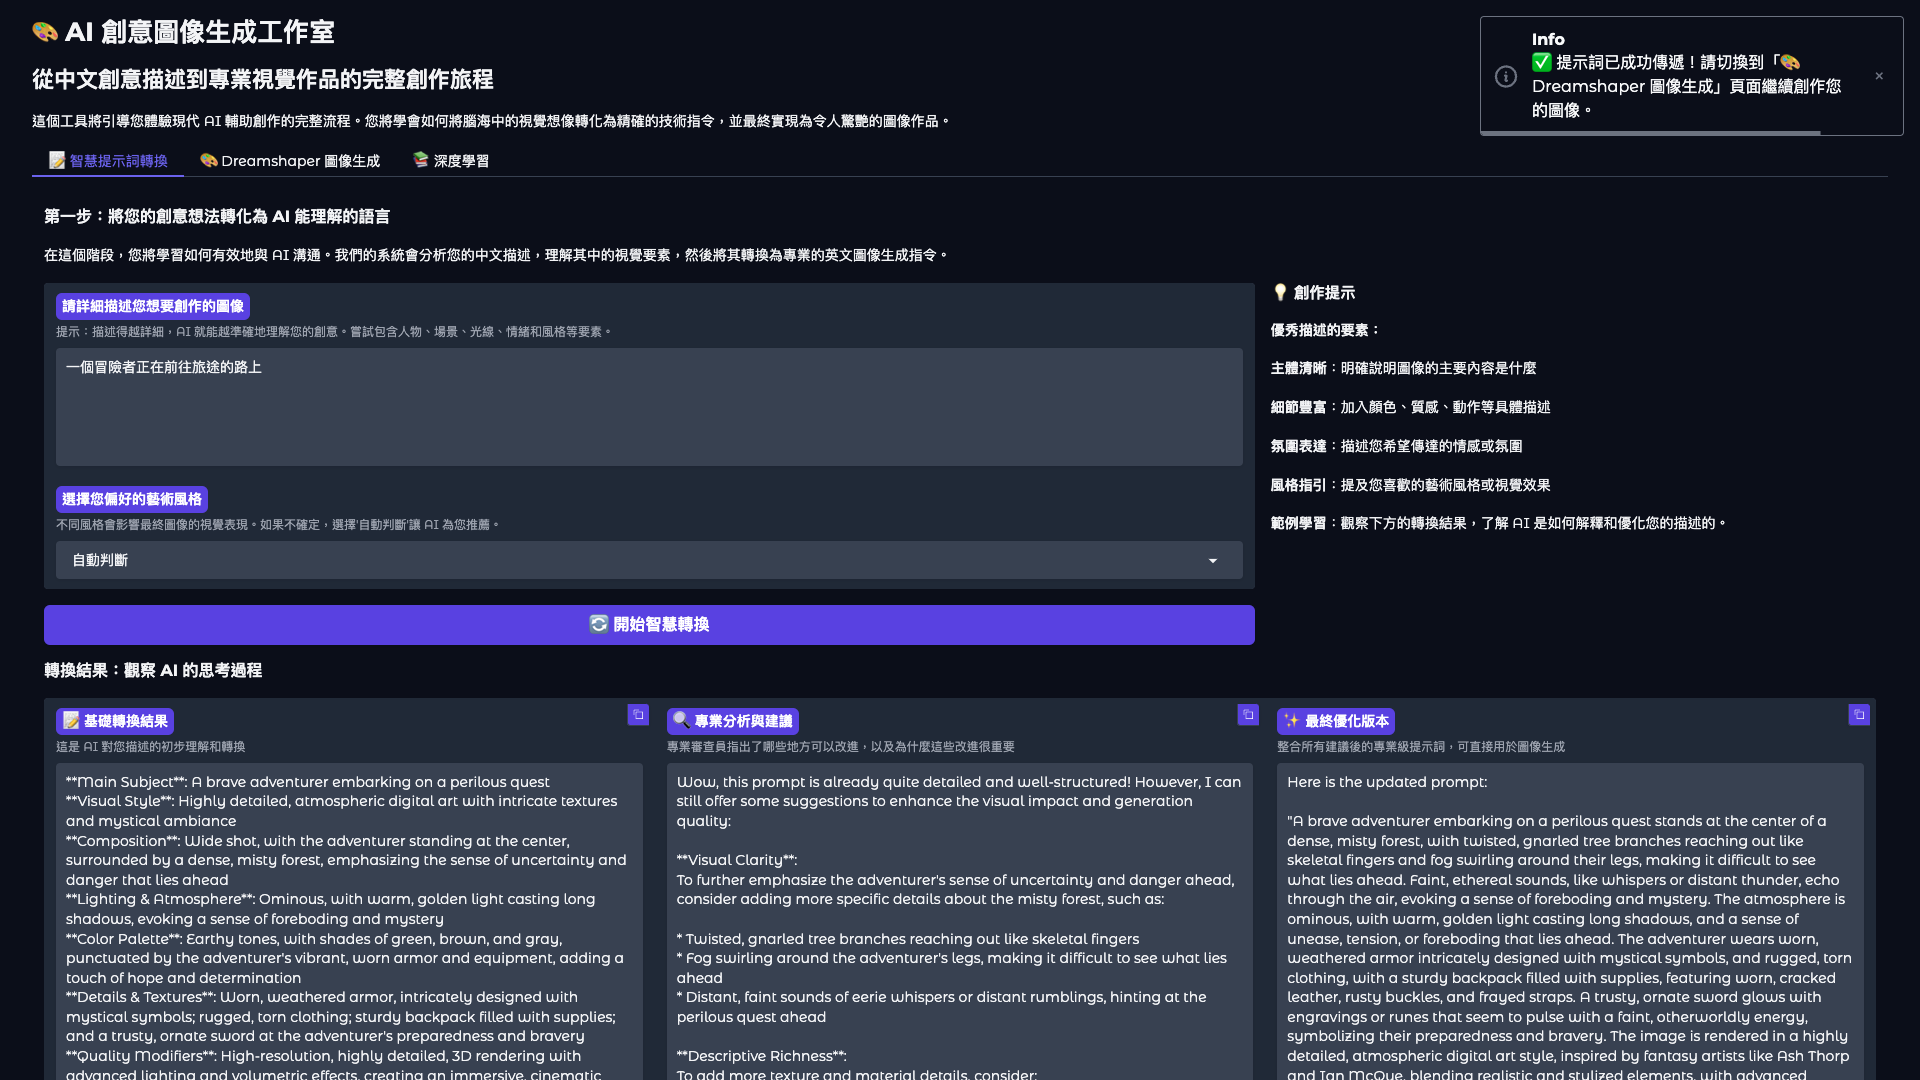

### 第二頁面：Dreamshaper 圖像生成 - 從概念到視覺的實現
- 如果說第一個頁面是語言的藝術，那麼第二個頁面就是技術的科學。這個頁面將經過優化的提示詞轉化為實際的視覺作品，但它做的遠不止於此，它還承擔著技術教育的重要使命。
- 左側的控制面板設計得像一個專業攝影師的工作台。每個參數都不僅有其技術功能，更有其教育意義。當用戶看到「生成步數」這個滑桿時，配套的說明「更多步數通常產生更好品質，但需要更長時間」幫助他們理解品質與效率之間的平衡關係。這種設計讓用戶在調整參數的過程中自然地學習到 AI 圖像生成的技術原理。
- 品質增強和負面提示詞的設計特別值得關注。這兩個功能向用戶展示了 AI 圖像生成中一個重要的哲學概念：創作不僅是關於你想要什麼，同樣重要的是明確你不想要什麼。透過預設的品質增強關鍵詞「masterpiece, ultra high quality, intricate skin details, cinematic lighting」，用戶學會了如何使用技術術語來提升圖像品質。
- 隨機種子功能的加入展現了系統對 AI 本質的深度理解。通過讓用戶控制隨機性，系統教導了一個重要概念：AI 創作中的可重現性和實驗性。這就像教授一位藝術家如何在創作中平衡計劃性和偶然性。
- 右側的展示區域不僅是結果的呈現空間，更是學習的延續。畫廊式的布局讓用戶可以同時比較多個生成結果，培養他們的視覺判斷能力。下方的創作技巧指導繼續強化著實驗精神和反思習慣的培養。
- 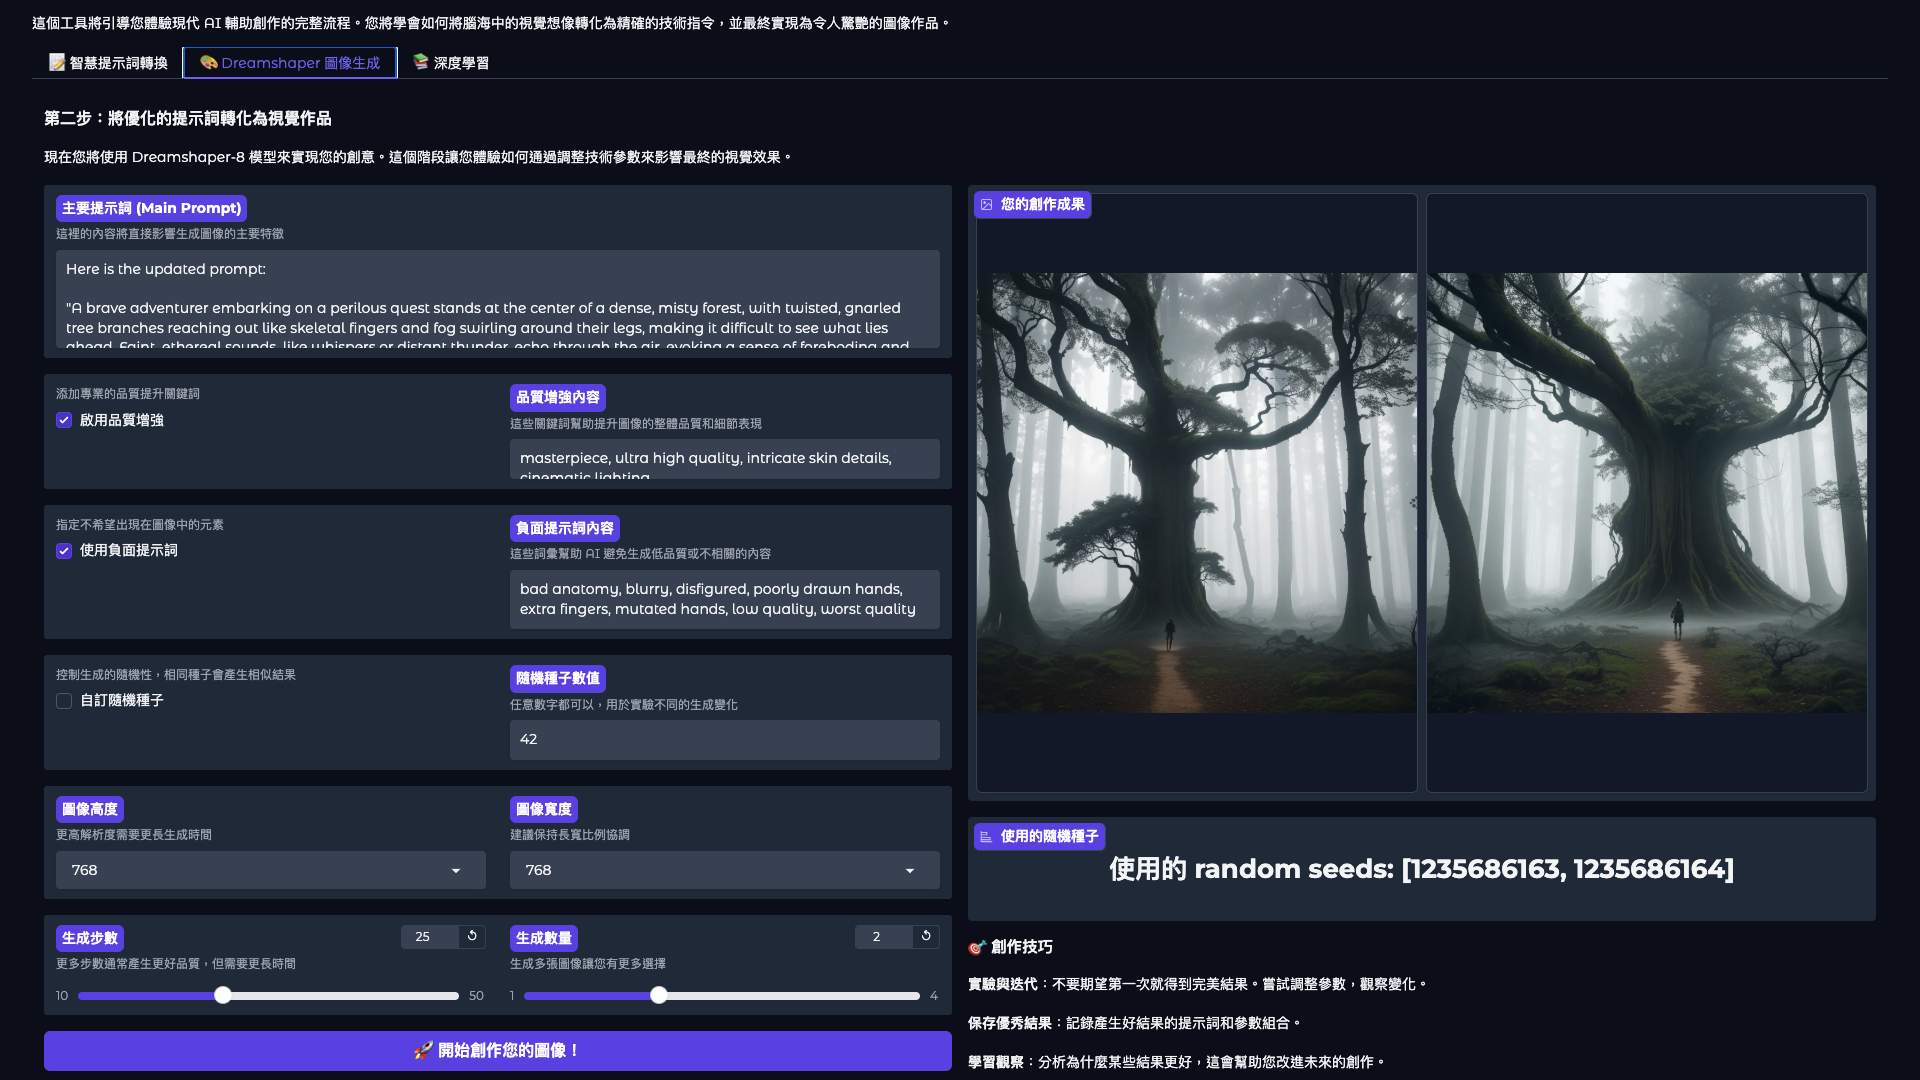

### 第三頁面：深度學習資源 - 知識體系的建構

- 這個頁面承擔著整個系統最重要的長期教育使命。它不滿足於僅僅教會用戶如何使用工具，而是要幫助他們建立起完整的知識框架和理論基礎。
- 頁面的結構採用了經典的教育學設計：從原理理解開始，逐步深入到實踐應用，最後擴展到進階技巧。這種循序漸進的安排符合人類學習的認知規律。
- 「理解提示詞工程的核心原理」部分將技術概念與人文理解相結合。當系統解釋「AI 圖像生成模型通過分析大量的圖像和文字配對來學習視覺概念」時，它實際上在幫助用戶建立起對 AI 學習機制的直觀理解。這種理解對於用戶將來的獨立創作至關重要。
- 「常見挑戰與解決策略」部分體現了問題導向的學習方法。通過預先識別用戶可能遇到的困難並提供解決方案，系統展現了豐富的實踐智慧。這就像一位經驗豐富的老師分享多年來收集的常見錯誤和解決方法。
- 「進階創作技巧」部分則將技術技能提升到藝術層面。當系統討論「情緒傳達」和「細節平衡」時，它實際上在培養用戶的藝術素養和美學判斷力。這種設計體現了對 AI 輔助創作本質的深刻理解：技術和藝術必須完美融合。
- 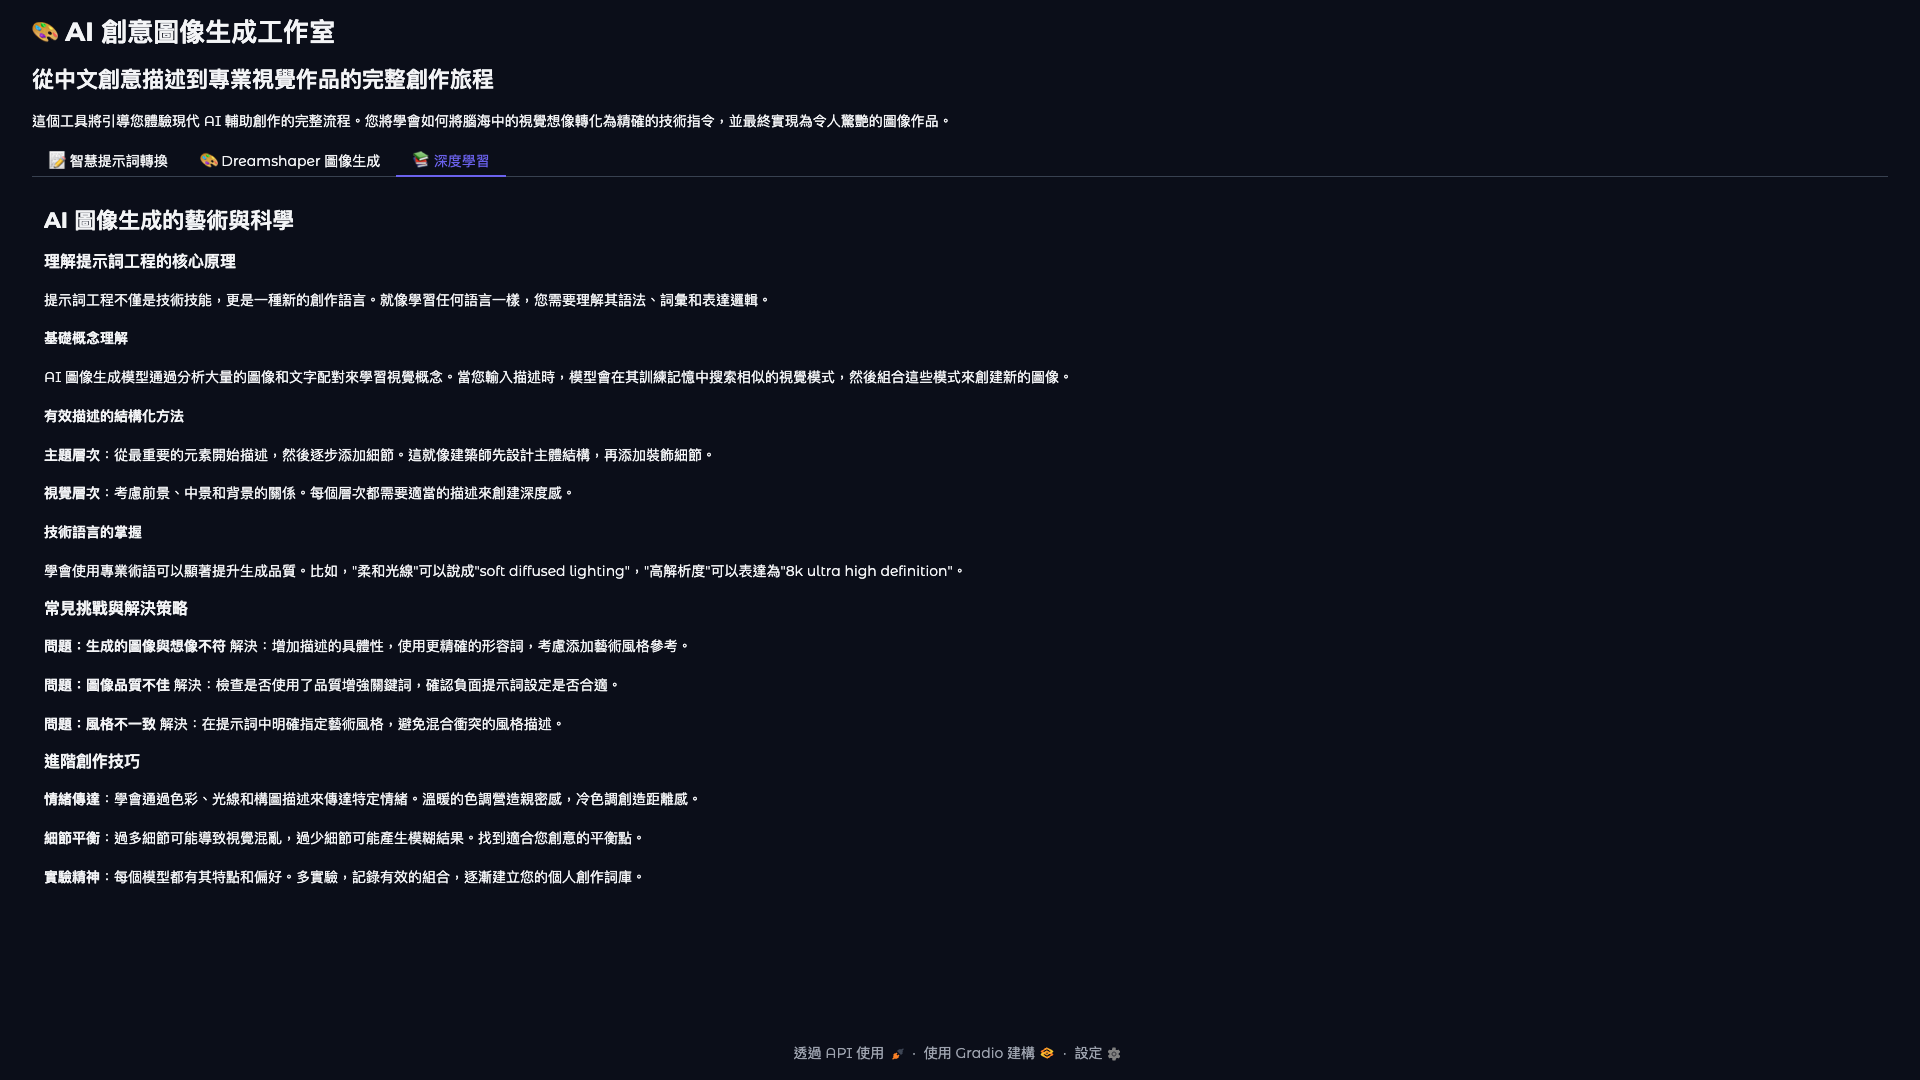

#### 讀入金鑰

In [ ]:
import os
from google.colab import userdata

In [ ]:
#【使用 Groq】
api_key = userdata.get('Groq')
os.environ['GROQ_API_KEY']=api_key
provider = "groq"
model = "llama3-70b-8192"

In [ ]:
!pip install aisuite[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.9/863.9 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.5/103.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 38.1 MB/s eta 0:00:00
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.16.1 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.2 which is incompatible.


### 基本的設定

In [ ]:
import aisuite as ai

In [ ]:
provider_writer = "groq"
model_writer="llama3-70b-8192"

provider_reviewer = "groq"
model_reviewer = "llama3-70b-8192"

#### 標準回應函式

In [ ]:
def reply(system="請幫我改寫成更具體的英文提示",
          prompt="hi",
          provider="groq",
          model="llama3-70b-8192"
          ):

    client = ai.Client()

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": prompt}
    ]


    response = client.chat.completions.create(model=f"{provider}:{model}", messages=messages)

    return response.choices[0].message.content

In [ ]:
system_writer = """You are a professional AI image generation prompt engineer, specializing in converting Chinese image requests into detailed English prompts that produce high-quality visual results.

When converting Chinese image descriptions to English prompts, structure your output like this:

**Main Subject**: The central focus of the image
**Visual Style**: Art style, technique, or aesthetic approach
**Composition**: Layout, perspective, and framing
**Lighting & Atmosphere**: Mood, time of day, lighting conditions
**Color Palette**: Dominant colors and color relationships
**Details & Textures**: Specific visual elements that enhance realism
**Quality Modifiers**: Technical parameters for better results

Key principles for effective image prompts:
- Use specific, vivid descriptive language
- Include artistic style references (photorealistic, oil painting, digital art, etc.)
- Specify lighting conditions (golden hour, soft lighting, dramatic shadows)
- Add quality boosters (highly detailed, 8k resolution, professional photography)
- Consider composition elements (close-up, wide shot, rule of thirds)
- Include camera or artistic technique descriptions when relevant

Example conversion:
Chinese: "一隻橘色的貓躺在地上"
English: "A vibrant orange tabby cat lying peacefully on wooden floor, warm afternoon sunlight streaming through window, soft natural lighting, cozy domestic setting, highly detailed fur texture, professional pet photography, shallow depth of field, 8k resolution"

Transform the Chinese input into a rich, detailed English prompt that will generate compelling visual results."""

In [ ]:
system_reviewer = """You are an expert in AI image generation prompt optimization. Your role is to evaluate English image prompts and suggest improvements for better visual results.

Evaluate image prompts across these specific criteria:

**Visual Clarity**: Are the main subjects and scene clearly described?
**Descriptive Richness**: Does it include sufficient visual details (colors, textures, lighting)?
**Style Specification**: Is the artistic style or technique clearly defined?
**Composition Guidance**: Are framing and perspective adequately described?
**Technical Quality**: Does it include quality-enhancing keywords and parameters?
**Atmospheric Elements**: Are mood, lighting, and environmental details specified?

Common areas for improvement in image prompts:
- Adding specific lighting descriptions (golden hour, rim lighting, soft shadows)
- Including artistic style references (photorealistic, impressionist, digital art)
- Specifying camera angles and composition (bird's eye view, close-up portrait)
- Adding texture and material details (glossy, matte, weathered, silk)
- Including quality modifiers (highly detailed, 4k, professional photography)
- Describing color relationships and palettes

Provide specific suggestions to enhance visual impact and generation quality."""

In [ ]:
def reflect_post(prompt,
                 provider_writer="groq",
                 model_writer="llama3-70b-8192",
                 provider_reviewer="groq",
                 model_reviewer="llama3-70b-8192"):
    """
    三階段反思式提示詞優化流程

    Args:
        prompt: 使用者輸入的中文提示詞
        provider_writer: Writer 使用的 AI 服務提供者
        model_writer: Writer 使用的模型
        provider_reviewer: Reviewer 使用的 AI 服務提供者
        model_reviewer: Reviewer 使用的模型

    Returns:
        tuple: (初稿, 修改建議, 最終版本)
    """
    try:
        # 第一階段：生成初始英文 prompt
        first_version = reply(system_writer, prompt,
                              provider=provider_writer,
                              model=model_writer)

        # 第二階段：專業審查與建議
        suggestion = reply(system_reviewer, first_version,
                           provider=provider_reviewer,
                           model=model_reviewer)

        # 第三階段：根據建議優化
        improvement_prompt = f"""原始提示詞轉換：{first_version} 專業審查建議：{suggestion}
                                請根據上述建議重新優化這個英文 prompt，使其更加精確、完整且易於 AI 理解。
                                請直接輸出改進後的英文 prompt，不需要額外說明。"""

        second_version = reply(system_writer, improvement_prompt,
                               provider=provider_writer,
                               model=model_writer)

        return first_version, suggestion, second_version

    except Exception as e:
        error_message = f"處理過程中發生錯誤：{str(e)}"
        return error_message, error_message, error_message

### 4. 用 Gradio 打造你的對話機器人 Web App!

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.3/323.3 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.0 MB/s eta 0:00:00


In [ ]:
import gradio as gr

In [ ]:
!pip install diffusers transformers accelerate safetensors huggingface_hub gradio --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.1/512.1 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import userdata
from huggingface_hub import login # Import the login function

hf_token = userdata.get("HuggingFace")
login(token=hf_token)

In [ ]:
from diffusers import StableDiffusionPipeline, UniPCMultistepScheduler
import torch
import gc
import matplotlib.pyplot as plt
import gradio as gr
import random

In [ ]:
model_name = "Lykon/dreamshaper-8"

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    use_safetensors=True
).to("cuda")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/clip/feature_extraction_clip.py:30: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


In [ ]:
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

In [ ]:
def generate_images(prompt, use_enhance, enhance_text, use_negative, negative_text,
                    use_custom_seed, custom_seed, height, width, steps, num_images):

    height = int(height)
    width = int(width)

    if height % 8 != 0 or width % 8 != 0:
        raise ValueError("高度和寬度必須是8的倍數！")

    if use_custom_seed:
        base_seed = int(custom_seed)
    else:
        base_seed = random.randint(0, 2**32 - 1)

    seeds = [base_seed + i for i in range(num_images)]

    prompts = []
    negative_prompts = []
    generators = []

    final_prompt = prompt
    if use_enhance and enhance_text:
        final_prompt = prompt + ", " + enhance_text

    final_negative = negative_text if use_negative else None

    for seed in seeds:
        g = torch.Generator("cuda").manual_seed(seed)
        generators.append(g)
        prompts.append(final_prompt)
        negative_prompts.append(final_negative)

    gc.collect()
    torch.cuda.empty_cache()

    images = []
    for i in range(num_images):
        with torch.no_grad():
            image = pipe(
                prompt=prompts[i],
                negative_prompt=negative_prompts[i] if final_negative else None,
                height=height,
                width=width,
                num_inference_steps=steps,
                guidance_scale=7.5,
                generator=generators[i]
            ).images[0]
            images.append(image)

    return images, f"使用的 random seeds: {seeds}"

In [28]:
import gradio as gr

# 首先，讓我們定義核心的處理函數
# 這些函數體現了我們對 AI 輔助創作流程的理解

def enhanced_reflect_post(prompt, style_preference):
    """
    這個函數是我們系統的智慧核心，它實現了三階段的提示詞優化流程
    每個階段都有其獨特的教育價值和技術功能
    """
    # 當用戶選擇特定風格時，我們需要將這個偏好融入到處理過程中
    # 這體現了個性化學習的重要性
    if style_preference != "自動判斷":
        enhanced_prompt = f"{prompt}\n\n期望風格：{style_preference}"
    else:
        enhanced_prompt = prompt

    # 這裡調用您之前定義的 reflect_post 函數
    # 在實際實現中，您需要確保這個函數已經正確定義
    return reflect_post(enhanced_prompt)

def transfer_and_notify(enhanced_prompt):
    """
    這個函數不僅傳遞提示詞，還會顯示友善的引導訊息
    這體現了以用戶為中心的設計思維
    """
    # 首先顯示成功訊息，讓用戶知道操作已經完成
    gr.Info("✅ 提示詞已成功傳遞！請切換到「🎨 Dreamshaper 圖像生成」頁面繼續創作您的圖像。")

    # 然後返回傳遞的內容
    return enhanced_prompt

def complete_workflow(chinese_input, style_preference, use_enhance, enhance_text,
                     use_negative, negative_text, use_custom_seed, custom_seed,
                     height, width, steps, num_images):
    """
    這個函數實現了從概念到圖像的完整自動化工作流程
    它展示了如何將複雜的多步驟處理封裝成簡潔的用戶體驗
    """
    try:
        # 第一階段：智慧提示詞轉換
        basic, analysis, enhanced = enhanced_reflect_post(chinese_input, style_preference)

        # 第二階段：圖像生成（這裡您需要整合您的 generate_images 函數）
        images, seeds = generate_images(enhanced, use_enhance, enhance_text,
                                       use_negative, negative_text, use_custom_seed,
                                       custom_seed, height, width, steps, num_images)

        return basic, analysis, enhanced, images, seeds

    except Exception as e:
        # 優雅的錯誤處理確保用戶始終獲得有用的反饋
        error_msg = f"處理過程中遇到問題：{str(e)}"
        return error_msg, error_msg, error_msg, None, error_msg

# 圖像生成的預設配置
# 這些預設值基於實踐經驗，為新用戶提供良好的起點
default_enhance = "masterpiece, ultra high quality, intricate skin details, cinematic lighting"
default_negative = "bad anatomy, blurry, disfigured, poorly drawn hands, extra fingers, mutated hands, low quality, worst quality"

# 創建完整的用戶介面
# CSS 設計不僅考慮美觀，更重要的是支持學習體驗
with gr.Blocks(
    title="AI 創意圖像生成工作室",
    theme=gr.themes.Soft()
) as demo:

    # 主標題區域，設置整個應用的學習氛圍
    gr.Markdown("""
    # 🎨 AI 創意圖像生成工作室
    ## 從中文創意描述到專業視覺作品的完整創作旅程

    這個工具將引導您體驗現代 AI 輔助創作的完整流程。您將學會如何將腦海中的視覺想像轉化為精確的技術指令，並最終實現為令人驚艷的圖像作品。
    """, elem_classes=["content-section"])

    # 使用標籤頁組織不同的學習和創作階段
    with gr.Tabs():

        # 第一標籤：提示詞轉換與學習
        with gr.Tab("📝 智慧提示詞轉換"):

            gr.Markdown("""
            ### 第一步：將您的創意想法轉化為 AI 能理解的語言

            在這個階段，您將學習如何有效地與 AI 溝通。我們的系統會分析您的中文描述，理解其中的視覺要素，然後將其轉換為專業的英文圖像生成指令。
            """, elem_classes=["content-section"])

            # 輸入區域的設計考慮了用戶的學習需求
            with gr.Row():
                with gr.Column(scale=2):

                    # 這個輸入框的設計鼓勵用戶進行詳細的描述
                    user_input = gr.Textbox(
                        label="請詳細描述您想要創作的圖像",
                        placeholder="試試這樣描述：一位穿著飄逸白裙的少女站在薰衣草田中，夕陽西下時分，微風輕撫，整個畫面充滿寧靜詩意的氛圍，希望有水彩畫的柔美質感",
                        lines=5,
                        info="提示：描述得越詳細，AI 就能越準確地理解您的創意。嘗試包含人物、場景、光線、情緒和風格等要素。"
                    )

                    # 風格選擇器幫助用戶理解不同藝術風格的特點
                    style_preference = gr.Dropdown(
                        choices=[
                            "自動判斷",
                            "攝影寫實風格 - 如同專業攝影作品",
                            "數位插畫風格 - 現代電腦繪圖質感",
                            "傳統油畫風格 - 經典藝術繪畫",
                            "水彩畫風格 - 柔美透明質感",
                            "日系動漫風格 - 精緻卡通美學",
                            "電影視覺風格 - 戲劇化光影效果"
                        ],
                        value="自動判斷",
                        label="選擇您偏好的藝術風格",
                        info="不同風格會影響最終圖像的視覺表現。如果不確定，選擇'自動判斷'讓 AI 為您推薦。"
                    )

                    convert_btn = gr.Button(
                        "🔄 開始智慧轉換",
                        variant="primary",
                        size="lg"
                    )

                # 學習指導區域，提供實時的教育支持
                with gr.Column(scale=1):
                    gr.Markdown("""
                    #### 💡 創作提示

                    **優秀描述的要素：**

                    **主體清晰**：明確說明圖像的主要內容是什麼

                    **細節豐富**：加入顏色、質感、動作等具體描述

                    **氛圍表達**：描述您希望傳達的情感或氛圍

                    **風格指引**：提及您喜歡的藝術風格或視覺效果

                    **範例學習**：觀察下方的轉換結果，了解 AI 是如何解釋和優化您的描述的。
                    """, elem_classes=["highlight-box"])

            # 三欄式結果展示，體現完整的學習過程
            gr.Markdown("### 轉換結果：觀察 AI 的思考過程", elem_classes=["content-section"])

            with gr.Row():
                output_basic = gr.Textbox(
                    label="📝 基礎轉換結果",
                    lines=8,
                    info="這是 AI 對您描述的初步理解和轉換",
                    show_copy_button=True,
                    interactive=False
                )

                output_analysis = gr.Textbox(
                    label="🔍 專業分析與建議",
                    lines=8,
                    info="專業審查員指出了哪些地方可以改進，以及為什麼這些改進很重要",
                    show_copy_button=True,
                    interactive=False
                )

                output_enhanced = gr.Textbox(
                    label="✨ 最終優化版本",
                    lines=8,
                    info="整合所有建議後的專業級提示詞，可直接用於圖像生成",
                    show_copy_button=True,
                    interactive=False
                )

            # 工作流程連接按鈕
            with gr.Row():
                transfer_btn = gr.Button(
                    "➡️ 使用優化提示詞生成圖像",
                    variant="secondary",
                    size="lg"
                )
                gr.Markdown("點擊此按鈕將優化的提示詞複製到圖像生成區域")

            # 連接轉換處理邏輯
            convert_btn.click(
                enhanced_reflect_post,
                inputs=[user_input, style_preference],
                outputs=[output_basic, output_analysis, output_enhanced]
            )

        # 第二標籤：圖像生成與實現
        with gr.Tab("🎨 Dreamshaper 圖像生成"):

            gr.Markdown("""
            ### 第二步：將優化的提示詞轉化為視覺作品

            現在您將使用 Dreamshaper-8 模型來實現您的創意。這個階段讓您體驗如何通過調整技術參數來影響最終的視覺效果。
            """, elem_classes=["content-section"])

            with gr.Row():
                # 左側控制面板，教育用戶理解各種技術參數
                with gr.Column(scale=6):

                    # 主要提示詞輸入，可接收來自轉換系統的內容
                    prompt = gr.Textbox(
                        label="主要提示詞 (Main Prompt)",
                        placeholder="可以直接輸入，或從提示詞轉換頁面傳遞",
                        lines=4,
                        info="這裡的內容將直接影響生成圖像的主要特徵"
                    )

                    # 品質增強選項，教育用戶理解圖像品質的技術要素
                    with gr.Row():
                        use_enhance = gr.Checkbox(
                            label="啟用品質增強",
                            value=True,
                            info="添加專業的品質提升關鍵詞"
                        )
                        enhance_text = gr.Textbox(
                            label="品質增強內容",
                            value=default_enhance,
                            info="這些關鍵詞幫助提升圖像的整體品質和細節表現"
                        )

                    # 負面提示詞，教育用戶理解如何避免不想要的視覺元素
                    with gr.Row():
                        use_negative = gr.Checkbox(
                            label="使用負面提示詞",
                            value=True,
                            info="指定不希望出現在圖像中的元素"
                        )
                        negative_text = gr.Textbox(
                            label="負面提示詞內容",
                            value=default_negative,
                            info="這些詞彙幫助 AI 避免生成低品質或不相關的內容"
                        )

                    # 隨機種子控制，教育用戶理解 AI 生成的隨機性
                    with gr.Row():
                        use_custom_seed = gr.Checkbox(
                            label="自訂隨機種子",
                            value=False,
                            info="控制生成的隨機性，相同種子會產生相似結果"
                        )
                        custom_seed = gr.Number(
                            label="隨機種子數值",
                            value=42,
                            info="任意數字都可以，用於實驗不同的生成變化"
                        )

                    # 圖像尺寸設定，教育用戶理解不同尺寸的適用場景
                    with gr.Row():
                        height = gr.Dropdown(
                            ["512", "768", "1024"],
                            label="圖像高度",
                            value="768",
                            info="更高解析度需要更長生成時間"
                        )
                        width = gr.Dropdown(
                            ["512", "768", "1024"],
                            label="圖像寬度",
                            value="768",
                            info="建議保持長寬比例協調"
                        )

                    # 生成參數，教育用戶理解品質與速度的平衡
                    with gr.Row():
                        steps = gr.Slider(
                            10, 50,
                            value=25,
                            step=5,
                            label="生成步數",
                            info="更多步數通常產生更好品質，但需要更長時間"
                        )
                        num_images = gr.Slider(
                            1, 4,
                            step=1,
                            value=2,
                            label="生成數量",
                            info="生成多張圖像讓您有更多選擇"
                        )

                    generate_btn = gr.Button(
                        "🚀 開始創作您的圖像！",
                        variant="primary",
                        size="lg"
                    )

                # 右側結果展示區域
                with gr.Column(scale=6):
                    gallery = gr.Gallery(
                        label="您的創作成果",
                        columns=2,
                        object_fit="contain",
                        height="600px"
                    )
                    seed_info = gr.Label(label="使用的隨機種子")

                    # 創作指導信息
                    gr.Markdown("""
                    #### 🎯 創作技巧

                    **實驗與迭代**：不要期望第一次就得到完美結果。嘗試調整參數，觀察變化。

                    **保存優秀結果**：記錄產生好結果的提示詞和參數組合。

                    **學習觀察**：分析為什麼某些結果更好，這會幫助您改進未來的創作。
                    """, elem_classes=["highlight-box"])

            # 連接圖像生成邏輯
            generate_btn.click(
                fn=generate_images,  # 您需要確保這個函數已正確定義
                inputs=[prompt, use_enhance, enhance_text, use_negative, negative_text,
                        use_custom_seed, custom_seed, height, width, steps, num_images],
                outputs=[gallery, seed_info]
            )

            # 實現提示詞傳遞功能
            transfer_btn.click(
                fn=transfer_and_notify,
                inputs=[output_enhanced],
                outputs=[prompt]
            )

        # 第三標籤：學習資源與進階技巧
        with gr.Tab("📚 深度學習"):

            gr.Markdown("""
            ## AI 圖像生成的藝術與科學

            ### 理解提示詞工程的核心原理

            提示詞工程不僅是技術技能，更是一種新的創作語言。就像學習任何語言一樣，您需要理解其語法、詞彙和表達邏輯。

            **基礎概念理解**

            AI 圖像生成模型通過分析大量的圖像和文字配對來學習視覺概念。當您輸入描述時，模型會在其訓練記憶中搜索相似的視覺模式，然後組合這些模式來創建新的圖像。

            **有效描述的結構化方法**

            **主題層次**：從最重要的元素開始描述，然後逐步添加細節。這就像建築師先設計主體結構，再添加裝飾細節。

            **視覺層次**：考慮前景、中景和背景的關係。每個層次都需要適當的描述來創建深度感。

            **技術語言的掌握**

            學會使用專業術語可以顯著提升生成品質。比如，"柔和光線"可以說成"soft diffused lighting"，"高解析度"可以表達為"8k ultra high definition"。

            ### 常見挑戰與解決策略

            **問題：生成的圖像與想像不符**
            解決：增加描述的具體性，使用更精確的形容詞，考慮添加藝術風格參考。

            **問題：圖像品質不佳**
            解決：檢查是否使用了品質增強關鍵詞，確認負面提示詞設定是否合適。

            **問題：風格不一致**
            解決：在提示詞中明確指定藝術風格，避免混合衝突的風格描述。

            ### 進階創作技巧

            **情緒傳達**：學會通過色彩、光線和構圖描述來傳達特定情緒。溫暖的色調營造親密感，冷色調創造距離感。

            **細節平衡**：過多細節可能導致視覺混亂，過少細節可能產生模糊結果。找到適合您創意的平衡點。

            **實驗精神**：每個模型都有其特點和偏好。多實驗，記錄有效的組合，逐漸建立您的個人創作詞庫。
            """, elem_classes=["content-section"])

# 啟動完整的學習和創作環境
if __name__ == "__main__":
    demo.launch(
        share=True,  # 允許分享連結
        server_name="0.0.0.0",  # 允許外部訪問
        # server_port=7860,  # 指定端口
        show_error=True  # 顯示詳細錯誤信息，便於學習和調試
    )

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e33df048fc6a79efb6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
